# Metadata

In [1]:
from pathlib import Path

import pandas as pd

from metadata import MetadataConfig, export_datasets, filter_lung, load_sample, obs_rows_for_srx
from metadata.viz import plot_cell_count_distribution, plot_disease_breakdown, plot_sample_breakdown

ROOT = Path().resolve().parents[0]

## Config

In [2]:
# --- config ---
_DATA_DIR = ROOT / "data/scbasecount/2026-01-12/metadata/GeneFull/Homo_sapiens"

cfg = MetadataConfig(
    sampleParquetPath=_DATA_DIR / "scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_sample_metadata.parquet",
    obsParquetPath=_DATA_DIR / "scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_obs_metadata.parquet",
    minObsCount=1000,
    outputDir=ROOT / "output/metadata",
)

## Load and Filter

In [3]:
sample = load_sample(cfg)
result = filter_lung(sample, cfg)
print(f"Loaded {len(sample):,} samples")

Loaded 35,266 samples


## Summary

In [4]:
# summary counts
n_total  = len(sample)
n_floor  = (sample["obs_count"] < cfg.minObsCount).sum()
n_known  = len(result.sampleKnown)
n_union  = len(result.lungUnion)
n_inter  = len(result.lungIntersection)
n_cancer = len(result.lungIntersectionCancer)

pd.DataFrame([
    {"subset": "total samples",                       "n": n_total},
    {"subset": f"dropped (< {cfg.minObsCount} cells)", "n": n_floor},
    {"subset": "known disease + tissue",               "n": n_known},
    {"subset": "lung union (disease OR tissue)",       "n": n_union},
    {"subset": "lung intersection (disease AND tissue)","n": n_inter},
    {"subset": "lung intersection - cancer only",      "n": n_cancer},
])

,subset,n
0,total samples,35266
1,dropped (< 1000 cells),1929
2,known disease + tissue,17531
3,lung union (disease OR tissue),7484
4,lung intersection (disease AND tissue),801
5,lung intersection - cancer only,346


## Visualisations

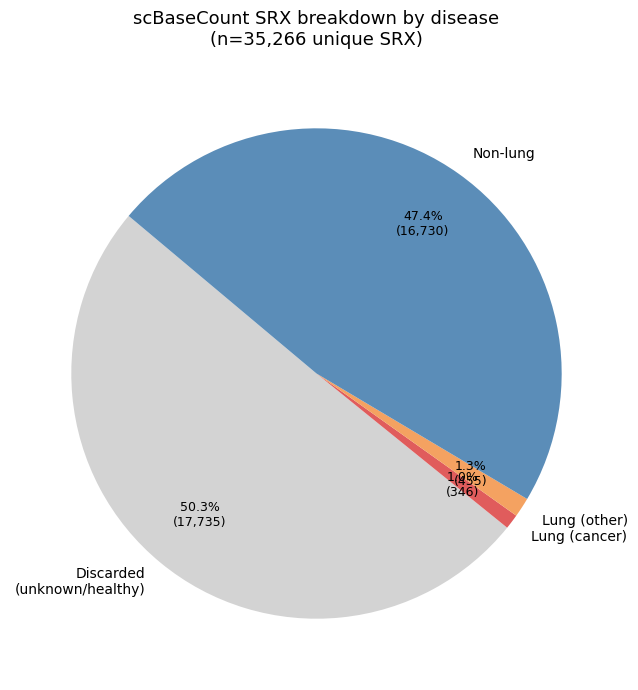

In [5]:
plot_sample_breakdown(sample, result, figs_dir=ROOT / "output/metadata/figs")

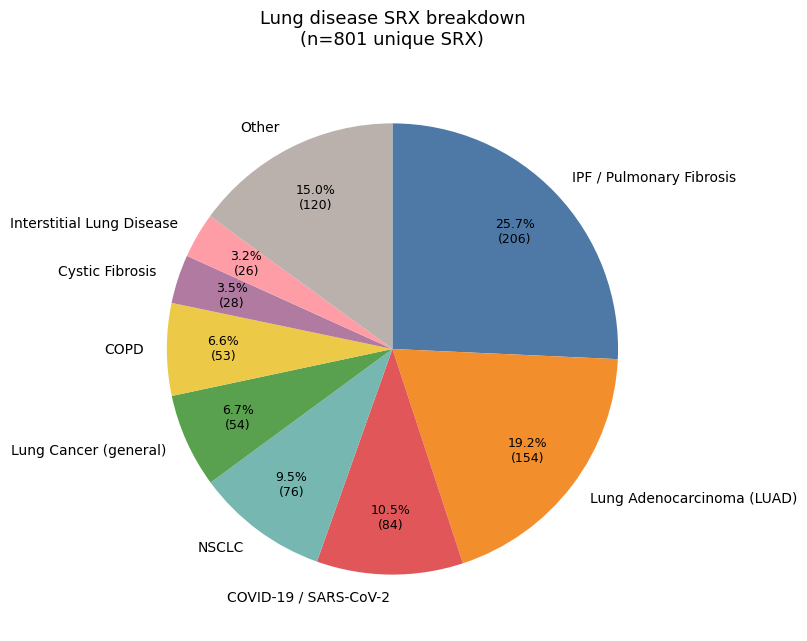

In [6]:
plot_disease_breakdown(result, figs_dir=ROOT / "output/metadata/figs")

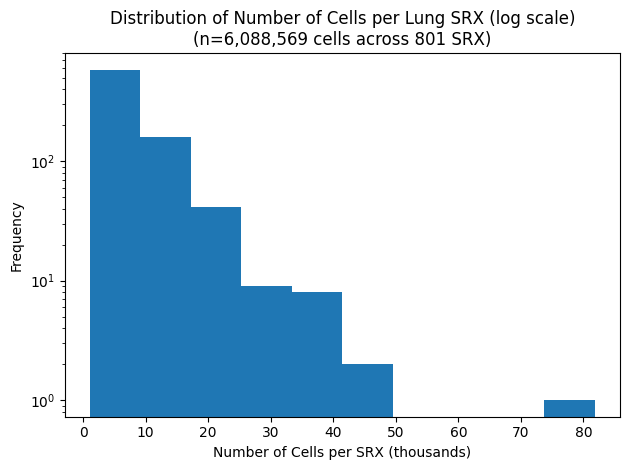

In [7]:
plot_cell_count_distribution(result, figs_dir=ROOT / "output/metadata/figs")

## Export

In [8]:
datasets_path, quantiles_path = export_datasets(result, cfg)
print(f"datasets.csv:          {datasets_path}")
print(f"quantiles_datasets.csv: {quantiles_path}")

datasets.csv:          /Users/otodreas/Desktop/Work/Nygen/scBaseCount_Pipeline/output/metadata/datasets.csv
quantiles_datasets.csv: /Users/otodreas/Desktop/Work/Nygen/scBaseCount_Pipeline/output/metadata/quantiles_datasets.csv


## Spot Check

In [9]:
# spot check: obs-level cell type breakdown for the largest SRX
biggest_srx = result.lungIntersection.loc[
    result.lungIntersection["obs_count"].idxmax(), "srx_accession"
]
print(f"Largest SRX: {biggest_srx} ({result.lungIntersection['obs_count'].max():,} cells)")
obs_rows_for_srx(biggest_srx, cfg)["cell_type"].value_counts()

Largest SRX: SRX19352021 (81,811 cells)


cell_type
    81811
Name: count, dtype: int64